# 02 - EDA dirigido a la problemática (es_incapacitante)

A diferencia de `01_eda_accidentes.ipynb` (descriptivo, sobre 2023-2024),
este notebook trabaja **solo sobre `accidentes_historico_2012_2022.csv`**
(única fuente con `gravedad`) y evalúa las X candidatas contra la variable
objetivo `es_incapacitante` (ver README, secciones 4-5, y
`reports/diccionario_datos.md`), organizado en 6 preguntas.

La lógica vive en `src/clean.py` (`derive_es_incapacitante`,
`normalize_turno`) y `src/eda.py` (`cramers_v`,
`tasa_incapacitante_por_categoria`) — este notebook solo importa y muestra.

**Las celdas `### Hallazgo` se dejan en blanco a propósito**: este
notebook calcula, no interpreta — la lectura de cada resultado la completa
el equipo después de revisarlo (ver CLAUDE.md: prohibido inventar
conclusiones).

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sys.path.append(str(Path.cwd().parent))

from src.clean import derive_es_incapacitante
from src.config import FIGURES_DIR
from src.eda import cramers_v, tasa_incapacitante_por_categoria
from src.ingest import load_historico_accidentes

sns.set_theme()
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

df = load_historico_accidentes()
y = derive_es_incapacitante(df["gravedad"])

print("shape df:", df.shape)
print("filas con etiqueta definida:", y.notna().sum(), "de", len(df))

shape df: (1028, 27)
filas con etiqueta definida: 1016 de 1028


## Pregunta 1: ¿Cómo se distribuye la variable objetivo `es_incapacitante`?

Necesario para saber qué tan desbalanceado está el problema de
clasificación antes de elegir métricas y estrategia de modelado (ver
README, sección 3).

gravedad
True     861
False    155
<NA>      12
Name: count, dtype: Int64

gravedad
True     84.74
False    15.26
Name: proportion, dtype: Float64


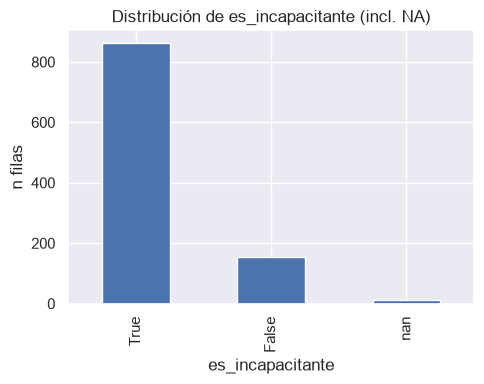

In [2]:
conteo_y = y.value_counts(dropna=False)
print(conteo_y)
print()
print((y.dropna().value_counts(normalize=True) * 100).round(2))

fig, ax = plt.subplots(figsize=(5, 4))
conteo_y.rename(index={True: "True", False: "False"}).plot(kind="bar", ax=ax)
ax.set_title("Distribución de es_incapacitante (incl. NA)")
ax.set_xlabel("es_incapacitante")
ax.set_ylabel("n filas")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "eda_dirigido_distribucion_target.png", dpi=100)

### Hallazgo

Sobre las 1016 filas con etiqueta definida: **84.74% `True` / 15.26%
`False`** (861 / 155) — desbalance ~85/15. Otras 12 filas quedan en `NA`
(10 sin dato de gravedad + 2 casos ambiguos ya decididos, ver README sección
4) y se excluyen de este análisis. Confirma lo esperado en la sección 3 del
README: con este desbalance, accuracy sola no sirve como métrica — hay que
priorizar recall/F1 sobre la clase minoritaria (`False`, no incapacitante).

## Pregunta 2: ¿Las variables numéricas candidatas están correlacionadas entre sí?

Solo `edad_anios` y `anio` son numéricas en esta fuente (`mes` es
categórica en texto, `experiencia_puesto` quedó fuera de X — ver README
sección 5). Sirve para descartar redundancia antes de modelar, no para
medir importancia.

,edad_anios,anio
edad_anios,1.000000,0.014233
anio,0.014233,1.000000


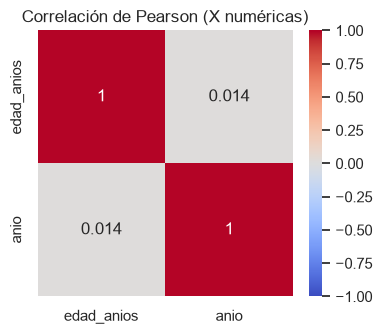

In [3]:
cols_numericas = ["edad_anios", "anio"]
corr = df[cols_numericas].corr()
display(corr)

fig, ax = plt.subplots(figsize=(4, 3.5))
sns.heatmap(corr, annot=True, vmin=-1, vmax=1, cmap="coolwarm", ax=ax)
ax.set_title("Correlación de Pearson (X numéricas)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "eda_dirigido_correlacion_numerica.png", dpi=100)

### Hallazgo

`edad_anios` y `anio` tienen correlación de Pearson **0.014** — prácticamente
nula. No hay redundancia entre las 2 únicas X numéricas: ambas aportan
información independiente, no hay motivo para descartar ninguna de las dos
por colinealidad.

## Pregunta 3: ¿Qué tan asociadas están con `es_incapacitante` las categóricas de cardinalidad manejable?

`sexo`, `turno`, `mes`, `programa`, `area_responsabilidad`,
`actividad_realizada`. Cramér's V va de 0 (sin asociación) a 1 (asociación
perfecta) — el equivalente a una correlación para categóricas, donde
Pearson no aplica.

actividad_realizada     0.6401
programa                0.5705
area_responsabilidad    0.3440
turno                   0.2709
mes                     0.2127
sexo                    0.1589
Name: cramers_v, dtype: float64

--- sexo ---


,n,pct_incapacitante
categoria,,
M,572,81.47
F,98,65.31
-,1,0.0



--- turno ---


,n,pct_incapacitante
categoria,,
DIA,323,81.11
TARDE,220,73.64
NOCHE,136,79.41
TURNO_1,119,100.0
TURNO_2,76,100.0
TURNO_3,45,100.0


...

,n,pct_incapacitante
categoria,,
GALLETERA LIMA,115,56.52
COPSA,70,68.57
TEAL,63,98.41
SI,61,100.0
DISTRIBUCION LIMA,36,69.44
DETERGENTES,32,65.62
BOLIVIA,31,90.32
ADMINISTRACION,28,85.71
MOLINO FAUCETT,26,88.46



--- area_responsabilidad ---


,n,pct_incapacitante
categoria,,
PRODUCCION,252,93.25
DISTRIBUCION,64,100.0
ADMINISTRACION,36,80.56
GLOBAL,34,100.0
PROYECTOS,28,100.0
MANTENIMIENTO,27,96.3
VITAPRO,13,100.0
ALMACEN DE INSUMOS,13,84.62
RELACIONES LABORALES,13,100.0



--- actividad_realizada ---


,n,pct_incapacitante
categoria,,
DURANTE OPERACION PRODUCTIVA,282,87.23
DURANTE SU RUTINA DE TRABAJO,212,99.06
OTROS,75,45.33
TRASLADANDOSE A PIE,68,75.0
MANTENIMIENTO,60,98.33
CARGA/DESCARGA DE CAMION,33,100.0
TRASLADANDOSE,32,100.0
DURANTE RUTINA DE TRABAJO,32,31.25
LIMPIANDO EQUIPO,29,100.0


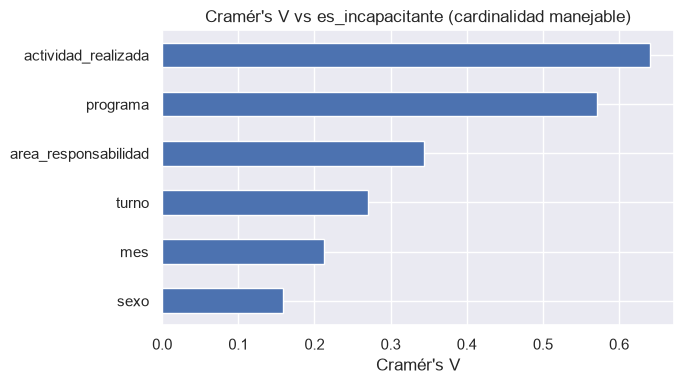

In [4]:
cols_categoricas_ok = [
    "sexo", "turno", "mes", "programa", "area_responsabilidad", "actividad_realizada"
]

v_categoricas = pd.Series(
    {col: cramers_v(df[col], y) for col in cols_categoricas_ok}, name="cramers_v"
).sort_values(ascending=False)
display(v_categoricas.round(4))

fig, ax = plt.subplots(figsize=(7, 4))
v_categoricas.plot(kind="barh", ax=ax)
ax.set_title("Cramér's V vs es_incapacitante (cardinalidad manejable)")
ax.set_xlabel("Cramér's V")
ax.invert_yaxis()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "eda_dirigido_cramers_v_manejable.png", dpi=100)

for col in cols_categoricas_ok:
    print(f"--- {col} ---")
    display(tasa_incapacitante_por_categoria(df[col], y).head(10))
    print()

### Hallazgo

Orden de asociación con `es_incapacitante` (Cramér's V): `actividad_realizada`
(0.64) > `programa` (0.57) > `area_responsabilidad` (0.34) > `turno` (0.27) >
`mes` (0.21) > `sexo` (0.16). Las 2 más asociadas (`actividad_realizada`,
`programa`) son candidatas fuertes para el modelo; `sexo` es la más débil de
este grupo, aunque no despreciable (0.16 no es 0).

Un patrón concreto en las tablas de tasa: el esquema de `turno` numerado
(`TURNO_1/2/3`) muestra **100% incapacitante** en los 3 casos (n=119, 76,
45), mientras el esquema de franja horaria (`DIA`/`TARDE`/`NOCHE`) muestra
73-81%. Como son dos convenciones de registro distintas y no unificadas (ver
README sección 8), esto podría reflejar que ambas convenciones se usaron en
períodos o criterios de registro distintos — no se puede concluir causalidad
sin revisar el criterio de negocio con el equipo de SST.

## Pregunta 4: ¿Qué tan asociadas están con `es_incapacitante` las categóricas de cardinalidad muy alta?

`lugar` (371 categorías), `fuente_peligro` (359), `puesto_trabajo` (344)
sobre 1028 filas. **Cramér's V poco confiable por celdas con n<5;
interpretar solo el orden de magnitud.** Son prácticamente texto libre más
que categóricas — agruparlas requiere criterio de dominio que no tenemos
hoy (ver README, sección 9, pendiente).

--- lugar (371 categorias, top 10 por n) ---
  (poco confiable por celdas con n<5; interpretar solo el orden de magnitud)


,n,pct_incapacitante
categoria,,
COPSA,61,85.25
GALLETERA LIMA,45,95.56
DETERGENTES,42,88.1
GLOBAL,36,100.0
GALLETERA,28,28.57
NUTRICION ANIMAL TRUJILLO,27,100.0
SIDSUR,26,100.0
FIDEERIA LIMA,25,92.0
CDC,22,90.91



--- fuente_peligro (359 categorias, top 10 por n) ---
  (poco confiable por celdas con n<5; interpretar solo el orden de magnitud)


,n,pct_incapacitante
categoria,,
EQUIPO,122,100.0
PISO,55,87.27
OTROS,53,11.32
MAQUINA,38,44.74
CAMION,29,96.55
FAJA EN MOVIMIENTO,23,100.0
ESCALERA,23,91.3
PALETA,22,90.91
PUERTA,17,94.12



--- puesto_trabajo (344 categorias, top 10 por n) ---
  (poco confiable por celdas con n<5; interpretar solo el orden de magnitud)


,n,pct_incapacitante
categoria,,
PERSONAL ALICORP,100,100.0
TERCERO,88,100.0
OPERARIO DE PRODUCCION,63,90.48
AYUDANTE DE PLANTA,56,85.71
PERSONAL NO ALICORP,44,100.0
OPERARIO,31,51.61
OBRERO,30,16.67
MECANICO,18,100.0
PERSONAL TEAL,14,100.0


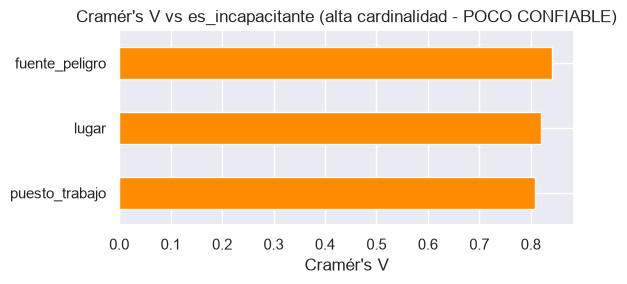

In [5]:
cols_categoricas_alta_cardinalidad = ["lugar", "fuente_peligro", "puesto_trabajo"]

v_alta_card = pd.Series(
    {col: cramers_v(df[col], y) for col in cols_categoricas_alta_cardinalidad}, name="cramers_v"
).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(6, 3))
v_alta_card.plot(kind="barh", ax=ax, color="darkorange")
ax.set_title("Cramér's V vs es_incapacitante (alta cardinalidad - POCO CONFIABLE)")
ax.set_xlabel("Cramér's V")
ax.invert_yaxis()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "eda_dirigido_cramers_v_alta_cardinalidad.png", dpi=100)

for col in cols_categoricas_alta_cardinalidad:
    n_cat = df[col].nunique()
    print(f"--- {col} ({n_cat} categorias, top 10 por n) ---")
    print("  (poco confiable por celdas con n<5; interpretar solo el orden de magnitud)")
    display(tasa_incapacitante_por_categoria(df[col], y).head(10))
    print()

### Hallazgo

Los 3 Cramér's V son altos (`fuente_peligro` 0.84, `lugar` 0.82,
`puesto_trabajo` 0.81) — más altos que cualquiera de la Pregunta 3 — pero
**no se pueden tomar al pie de la letra**: con 344-371 categorías sobre 1028
filas, la mayoría de categorías tiene 1-2 casos, y Cramér's V se infla
artificialmente con celdas así de chicas. No se puede concluir que estas 3
variables sean más predictivas que `actividad_realizada`/`programa` sin
antes agruparlas por criterio de dominio (decisión diferida, ver README
sección 9) — comparar un V de alta cardinalidad con uno de cardinalidad
manejable no es una comparación válida tal cual.

## Pregunta 5: ¿La tasa de incapacitantes cambia a lo largo de los años (2012-2022)?

Relevante para saber si el problema es estable o está cambiando en el
tiempo — no es una X candidata nueva, `anio` ya está en la sección de
correlación numérica; aquí se mira específicamente su relación con `y`.

,n,pct_incapacitante
categoria,,
2012,51,100.0
2013,70,100.0
2014,66,100.0
2015,46,100.0
2016,74,100.0
2017,72,100.0
2018,73,100.0
2019,222,49.1
2020,111,75.68


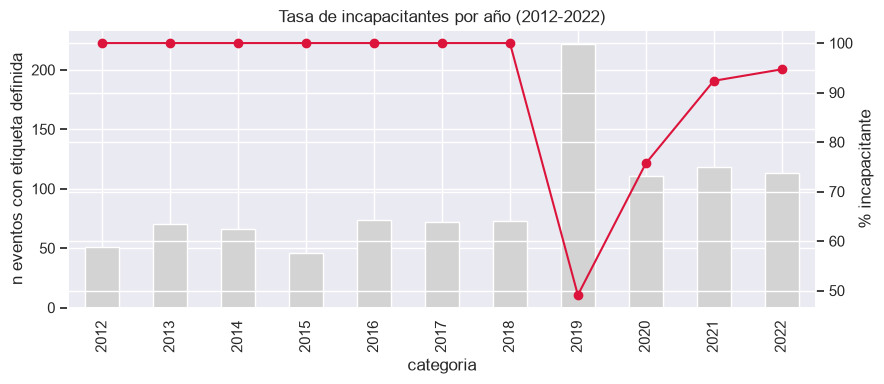

In [6]:
tasa_por_anio = tasa_incapacitante_por_categoria(df["anio"].astype("Int64").astype("category"), y)
tasa_por_anio = tasa_por_anio.sort_index()
display(tasa_por_anio)

fig, ax = plt.subplots(figsize=(9, 4))
ax2 = ax.twinx()
tasa_por_anio["n"].plot(kind="bar", ax=ax, color="lightgray", label="n")
tasa_por_anio["pct_incapacitante"].plot(kind="line", marker="o", ax=ax2, color="crimson")
ax.set_ylabel("n eventos con etiqueta definida")
ax2.set_ylabel("% incapacitante")
ax.set_title("Tasa de incapacitantes por año (2012-2022)")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "eda_dirigido_tasa_incapacitante_por_anio.png", dpi=100)

### Hallazgo

De 2012 a 2018 la tasa es 100% incapacitante todos los años (n entre 45 y
73 por año). En 2019 cae de golpe a ~50% (con el volumen más alto del
período, n≈223), y luego sube gradualmente: ~75% (2020), ~93% (2021), ~95%
(2022). Un salto tan abrupto y sostenido durante 7 años seguidos en 100%
exacto es más compatible con un cambio en el criterio o instrumento de
registro de `gravedad` a partir de 2019 (ej. se empezó a registrar
"ACCIDENTE NO INCAPACITANTE"/"INCIDENTE" con más consistencia) que con un
cambio real de siniestralidad — **esto es una hipótesis a verificar con el
equipo de SST, no una conclusión**, no hay forma de confirmarla solo con
estos datos.

## Pregunta 6: ¿La tasa de incapacitantes varía por turno/franja horaria?

Relevante directamente para la decisión de priorización (ver README,
sección 1): si un turno concentra más eventos incapacitantes, es una señal
operativa para el jefe de SST, no solo un dato descriptivo.

,n,pct_incapacitante
categoria,,
TURNO_1,119,100.0
TURNO_2,76,100.0
TURNO_3,45,100.0
DIA,323,81.11
NOCHE,136,79.41
TARDE,220,73.64


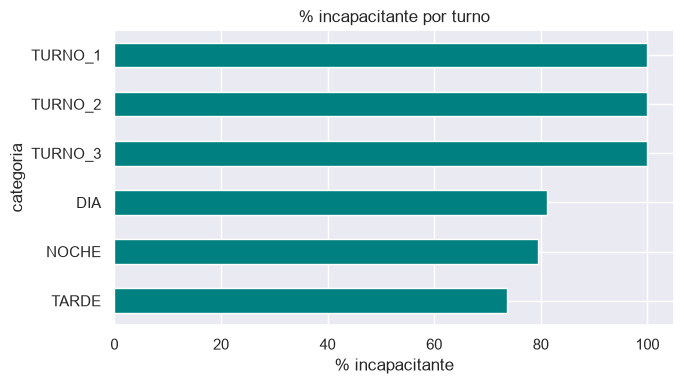

In [7]:
tasa_por_turno = tasa_incapacitante_por_categoria(df["turno"], y).sort_values(
    "pct_incapacitante", ascending=False
)
display(tasa_por_turno)

fig, ax = plt.subplots(figsize=(7, 4))
tasa_por_turno["pct_incapacitante"].plot(kind="barh", ax=ax, color="teal")
ax.set_title("% incapacitante por turno")
ax.set_xlabel("% incapacitante")
ax.invert_yaxis()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "eda_dirigido_tasa_incapacitante_por_turno.png", dpi=100)

### Hallazgo

`TURNO_1`, `TURNO_2` y `TURNO_3` muestran 100% incapacitante (n=119, 76, 45);
`DIA` (81.11%, n=323), `NOCHE` (79.41%, n=136) y `TARDE` (73.64%, n=220) son
más bajos y parecidos entre sí. Como ya se anotó en la Pregunta 3, esto
coincide con la separación entre los dos esquemas de registro de turno, no
necesariamente con una diferencia real de riesgo por franja horaria —
priorizar atención "por turno numerado" hoy sería en realidad priorizar por
qué convención de registro se usó, no por el momento del día. Antes de usar
esto para decidir prioridad de atención (ver README sección 1), hay que
resolver con el equipo si `TURNO_1/2/3` corresponde a un período/planta
específico que explique el 100%.

## Pendiente

- [x] Completar las 6 celdas `### Hallazgo` — hecho.
- [x] Decisión sobre `lugar`/`fuente_peligro`/`puesto_trabajo`: se difiere
      el agrupamiento (no se inventa una regla de dominio sin criterio
      verificable) — ver README sección 9.
- [x] Decisión sobre las 2 filas de `gravedad` ambiguas: quedan en `NA` —
      ver README sección 4.

**Genuinamente pendiente, no decidible con los datos disponibles:**

- [ ] `experiencia_puesto` sigue fuera de X (texto libre, unidades
      mezcladas) — normalizarla es una fase futura.
- [ ] Verificar con el equipo de SST la hipótesis de la Pregunta 5 (cambio
      de criterio de registro de `gravedad` en 2019) y la de la Pregunta 6
      (qué explica el 100% de `TURNO_1/2/3`) antes de usarlas para decidir
      prioridad de atención.